### Tim 15:
- Gymnastiar Al Khoarizmy 122450096
- Dea Mutia Risani 122450099

# Tugas 1
Memahami kosep preprae dan eksplorasi data untuk membuat visualisasi yang mengimplementasikan konsep Editorial Focus

# Editorial Focus

## Datasets

This dataset comprises a set of users and their visits to various points-of-interests (POIs) in eight cities. The user-POI visits are determined based on geo-tagged YFCC100M Flickr photos that are:


1.   Mapped to specific POIs location and POI categories; and
2.   Grouped into individual travel sequences (consecutive user-POI visits that differ by <8hrs). Other associated datasets are the "List of POIs" dataset ("POI-{cityName}.csv" files from "poiList-ijcai15.zip") and "POI Cost-Profit Table" dataset ("costProfCat-{cityName}POI-all.csv" files from "costProf-ijcai15.zip")

Link: https://drive.google.com/file/d/1ryshHuWKnBijXJgvaSCv-KsSUhVGhpIJ/view

Dataset:
1. Flickr User-POI Visits  https://drive.google.com/file/d/1ryshHuWKnBijXJgvaSCv-KsSUhVGhpIJ/view?pli=1
2. Gowalla https://www.yongliu.org/datasets/
3. NYC and Tokyo Check-in https://www.kaggle.com/datasets/chetanism/foursquare-nyc-and-tokyo-checkin-dataset/data

## Identifikasi cerita

Tujuan utama dari fokus editorial adalah untuk menentukan cerita yang ingin Anda sampaikan melalui data

## Perjelas dengan Pertanyaan

Saat mengembangkan fokus editorial, pikirkan tentang pertanyaan-pertanyaan apa yang ingin Anda jawab untuk pembaca melalui visualisasi data Anda. Ini membantu menentukan arah analisis yang akan dilakukan

# Task

Berdasarkan uraian di atas maka lakukan
1. Pahami dan deskripsikan datasets yang disediakan
2. Identifikasi cerita yang akan anda sampaikan berdasarkan dataset yang disediakan
3. Berdasarkan pada point 2, deskripisikan pertanyaan yang mungkin muncul dari pembaca dan berdasarkan pertanyaan tersebut, data apa yang akan ditampilkan (data abstraction)? mengapa pengguna ingin melihatnya melihatnya
4. Lakukan analisis visual pada dataset type tabel dengan menggunakan 0, 1, 2, ... key







---



# Flickr User-POI Visits <br>
Dataset ini menyediakan kumpulan interaksi antara pengguna dan POI (Point-of-Interest) yang berlimpah, diekstrak dari dataset Flickr YFCC100M. Dataset ini berfokus pada pemahaman perilaku pengguna dan pola perjalanan di delapan kota dengan menganalisis kunjungan mereka ke berbagai POI.<br>

Komponen utama dataset ini mencakup data kunjungan pengguna ke POI, daftar POI dengan informasi detail seperti kategori dan lokasi, serta tabel biaya-keuntungan untuk setiap kategori POI di setiap kota. Data kunjungan pengguna berasal dari foto Flickr yang diberi geotag dan dikelompokkan menjadi urutan perjalanan, sehingga memungkinkan analisis rute dan preferensi perjalanan pengguna. Informasi kategori POI memberikan lensa berharga untuk menganalisis minat pengguna dan membandingkan popularitas berbagai jenis objek wisata. Data biaya-keuntungan memungkinkan analisis aspek ekonomi pariwisata, termasuk profitabilitas berbagai kategori POI dan potensi dampaknya terhadap perilaku pengguna.<br>

Secara ringkas, dataset ini memberikan informasi komprehensif tentang interaksi pengguna-POI dalam konteks pariwisata, memungkinkan berbagai analisis dan aplikasi untuk memahami perilaku pengguna, pola perjalanan, dan ekonomi pariwisata. Dataset ini cocok untuk analisis pariwisata, sistem rekomendasi, perencanaan kota, dan layanan berbasis lokasi.

## Import Dataset and Necessary Libraries

In [ ]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# extract files /content/data-ijcai15.zip

!unzip /content/data-ijcai15.zip -d /content/

Archive:  /content/data-ijcai15.zip
   creating: /content/data-ijcai15/costProf-ijcai15/
  inflating: /content/data-ijcai15/costProf-ijcai15/costProfCat-BudaPOI-all.csv  
  inflating: /content/data-ijcai15/costProf-ijcai15/costProfCat-DelhPOI-all.csv  
  inflating: /content/data-ijcai15/costProf-ijcai15/costProfCat-EdinPOI-all.csv  
  inflating: /content/data-ijcai15/costProf-ijcai15/costProfCat-GlasPOI-all.csv  
  inflating: /content/data-ijcai15/costProf-ijcai15/costProfCat-OsakPOI-all.csv  
  inflating: /content/data-ijcai15/costProf-ijcai15/costProfCat-PertPOI-all.csv  
  inflating: /content/data-ijcai15/costProf-ijcai15/costProfCat-ToroPOI-all.csv  
  inflating: /content/data-ijcai15/costProf-ijcai15/costProfCat-VienPOI-all.csv  
  inflating: /content/data-ijcai15/costProf-ijcai15/README.txt  
   creating: /content/data-ijcai15/poiList-ijcai15/
  inflating: /content/data-ijcai15/poiList-ijcai15/POI-Buda.csv  
  inflating: /content/data-ijcai15/poiList-ijcai15/POI-Delh.csv  
  infl

In [ ]:
directory = '/content/data-ijcai15/costProf-ijcai15'

# Create an empty list to store dataframes
dfs = []

# Iterate through all csv files
for filename in os.listdir(directory):
  if filename.endswith('.csv'):
    filepath = os.path.join(directory, filename)
    try:
      # Read the CSV file into a DataFrame, specifying the delimiter
      df = pd.read_csv(filepath, delimiter=';')

      # Extract the city name from the filename using regex
      match = re.search(r'costProfCat-(.+?)POI-all', filename)
      if match:
        city_name = match.group(1)
      else:
        city_name = "Unknown"  # Handle cases where the pattern doesn't match

      # Add a 'cities' column to the DataFrame
      df['cities'] = city_name

      # Append the DataFrame to the list
      dfs.append(df)
    except pd.errors.ParserError as e:
      print(f"Error parsing file {filename}: {e}")  # Handle parsing errors gracefully
    except Exception as e:
      print(f"An error occurred while processing {filename}: {e}") # Handle other potential errors


# Concatenate all dataframes into a single dataframe
costProfCat = pd.concat(dfs, ignore_index=True)

# Print the first few rows of the resulting dataframe
print(costProfCat.head())

   from  to         cost  profit   category cities
0     1   2   272.066373     253  Amusement   Osak
1     1   3  7292.894911     599  Amusement   Osak
2     1   4  1203.034337     512  Amusement   Osak
3     1   5  8562.257901     315  Amusement   Osak
4     1   6  7937.207231     660  Amusement   Osak


In [ ]:
directory = '/content/data-ijcai15/poiList-ijcai15'

# Create an empty list to store dataframes
dfs = []

# Iterate through all csv files
for filename in os.listdir(directory):
  if filename.endswith('.csv'):
    filepath = os.path.join(directory, filename)
    try:
      # Read the CSV file into a DataFrame, specifying the delimiter
      df = pd.read_csv(filepath, delimiter=';')

      # Extract the city name from the filename using regex
      match = re.search(r'POI-(.+?)\.csv', filename)
      if match:
        city_name = match.group(1)
      else:
        city_name = "Unknown"  # Handle cases where the pattern doesn't match

      # Add a 'cities' column to the DataFrame
      df['cities'] = city_name

      # Append the DataFrame to the list
      dfs.append(df)
    except pd.errors.ParserError as e:
      print(f"Error parsing file {filename}: {e}")  # Handle parsing errors gracefully
    except Exception as e:
      print(f"An error occurred while processing {filename}: {e}") # Handle other potential errors


# Concatenate all dataframes into a single dataframe
poiList = pd.concat(dfs, ignore_index=True)

# Print the first few rows of the resulting dataframe
print(poiList.head())

   poiID                     poiName        lat       long     theme cities
0      1                  India_Gate  28.612864  77.229306  Building   Delh
1      2               Sansad_Bhavan  28.617189  77.208084  Building   Delh
2      3          Rashtrapati_Bhavan  28.614342  77.199803  Building   Delh
3      4  Connaught_Place,_New_Delhi  28.632780  77.219720      Park   Delh
4      5               Lodhi_Gardens  28.593000  77.220000      Park   Delh


In [ ]:
directory = '/content/data-ijcai15/userVisits-ijcai15'

# Create an empty list to store dataframes
dfs = []

# Iterate through all csv files
for filename in os.listdir(directory):
  if filename.endswith('.csv'):
    filepath = os.path.join(directory, filename)
    try:
      # Read the CSV file into a DataFrame, specifying the delimiter
      df = pd.read_csv(filepath, delimiter=';')
      # Extract the city name from the filename
      name_parts = filename[:-4].split('-') # Remove .csv and split by -
      if len(name_parts) > 2:
        city_name = name_parts[1]
      else:
        city_name = name_parts[-1]

      # Add a 'cities' column to the DataFrame
      df['cities'] = city_name

      # Append the DataFrame to the list
      dfs.append(df)
    except pd.errors.ParserError as e:
      print(f"Error parsing file {filename}: {e}")  # Handle parsing errors gracefully
    except Exception as e:
      print(f"An error occurred while processing {filename}: {e}") # Handle other potential errors

# Concatenate all dataframes into a single dataframe
userVisits = pd.concat(dfs, ignore_index=True)

# Print the first few rows of the resulting dataframe
print(userVisits.head())

      photoID        userID   dateTaken  poiID       poiTheme  poiFreq  seqID  \
0  8636126004  10126637@N02  1365314352     12  Architectural      709      1   
1  8635021631  10126637@N02  1365314896     11  Architectural      418      1   
2  7133494159  10216976@N05  1332119449     18      Religious      534      2   
3  7133492891  10216976@N05  1332119539     18      Religious      534      2   
4  7909379802  10297667@N06  1255940392     18      Religious      534      3   

  cities  
0   Delh  
1   Delh  
2   Delh  
3   Delh  
4   Delh  


## Reading and Understanding our Data

In [ ]:
print(userVisits.info())
print(poiList.info())
print(costProfCat.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153208 entries, 0 to 153207
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   photoID    153208 non-null  int64 
 1   userID     153208 non-null  object
 2   dateTaken  153208 non-null  int64 
 3   poiID      153208 non-null  int64 
 4   poiTheme   153208 non-null  object
 5   poiFreq    153208 non-null  int64 
 6   seqID      153208 non-null  int64 
 7   cities     153208 non-null  object
dtypes: int64(5), object(3)
memory usage: 9.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   poiID    236 non-null    int64  
 1   poiName  236 non-null    object 
 2   lat      236 non-null    float64
 3   long     236 non-null    float64
 4   theme    236 non-null    object 
 5   cities   236 non-null    object 
dtypes: float64(2), int64(1

In [ ]:
print("First 5 rows of our dataset:")
userVisits.head()

First 5 rows of our dataset:


,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID,cities
0,8636126004,10126637@N02,1365314352,12,Architectural,709,1,Delh
1,8635021631,10126637@N02,1365314896,11,Architectural,418,1,Delh
2,7133494159,10216976@N05,1332119449,18,Religious,534,2,Delh
3,7133492891,10216976@N05,1332119539,18,Religious,534,2,Delh
4,7909379802,10297667@N06,1255940392,18,Religious,534,3,Delh


In [ ]:
poiList.head()

,poiID,poiName,lat,long,theme,cities
0,1,India_Gate,28.612864,77.229306,Building,Delh
1,2,Sansad_Bhavan,28.617189,77.208084,Building,Delh
2,3,Rashtrapati_Bhavan,28.614342,77.199803,Building,Delh
3,4,"Connaught_Place,_New_Delhi",28.632780,77.219720,Park,Delh
4,5,Lodhi_Gardens,28.593000,77.220000,Park,Delh


In [ ]:
costProfCat.head()

,from,to,cost,profit,category,cities
0,1,2,272.066373,253,Amusement,Osak
1,1,3,7292.894911,599,Amusement,Osak
2,1,4,1203.034337,512,Amusement,Osak
3,1,5,8562.257901,315,Amusement,Osak
4,1,6,7937.207231,660,Amusement,Osak


In [ ]:
print("There are {} duplicates in the dataset.".format(userVisits.duplicated().sum()))
print("Checking for missing values in each column:")
print(userVisits.isnull().sum())

There are 0 duplicates in the dataset.
Checking for missing values in each column:
photoID      0
userID       0
dateTaken    0
poiID        0
poiTheme     0
poiFreq      0
seqID        0
cities       0
dtype: int64


In [ ]:
print("There are {} duplicates in the dataset.".format(poiList.duplicated().sum()))
print("Checking for missing values in each column:")
print(poiList.isnull().sum())

There are 0 duplicates in the dataset.
Checking for missing values in each column:
poiId        0
category     0
latitude     0
longitude    0
cities       0
dtype: int64


In [ ]:
print("There are {} duplicates in the dataset.".format(costProfCat.duplicated().sum()))
print("Checking for missing values in each column:")
print(costProfCat.isnull().sum())

There are 0 duplicates in the dataset.
Checking for missing values in each column:
from        0
to          0
cost        0
profit      0
category    0
cities      0
dtype: int64


## Exploratory Data Analysis

User Visits Data:
             photoID        userID                           time  \
count   1.532080e+05        153208                         153207   
unique           NaN          5595                            NaN   
top              NaN  31403562@N00                            NaN   
freq             NaN          8573                            NaN   
mean    5.393580e+09           NaN  2010-05-03 04:44:46.657163264   
min     3.381100e+04           NaN            1864-11-30 13:55:08   
25%     3.178005e+09           NaN     2008-08-23 02:16:13.500000   
50%     5.214482e+09           NaN            2010-08-20 04:03:30   
75%     7.669742e+09           NaN     2012-06-02 14:00:30.500000   
max     1.404852e+10           NaN            2014-04-27 00:15:13   
std     3.062570e+09           NaN                            NaN   

                poiID    poiTheme        poiFreq          seqID  cities  
count   153208.000000      153208  153208.000000  153208.000000  153208  
uniqu

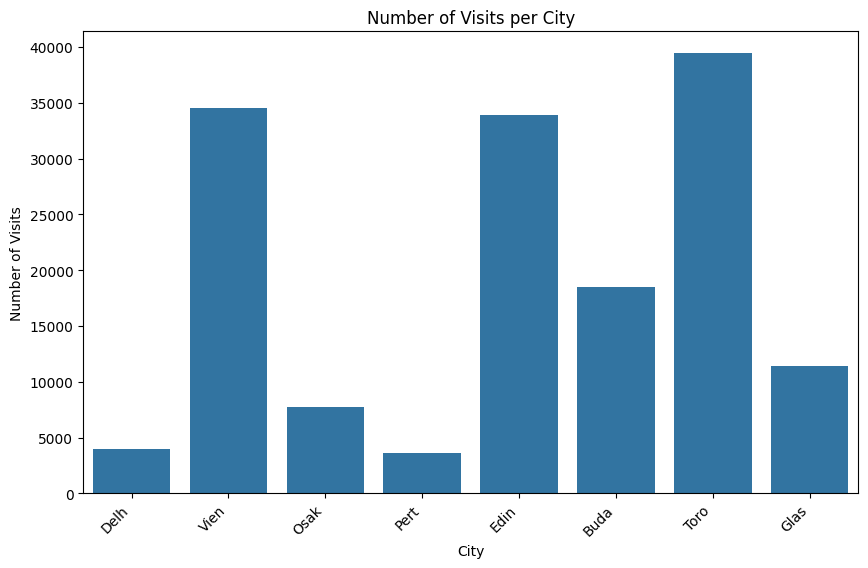

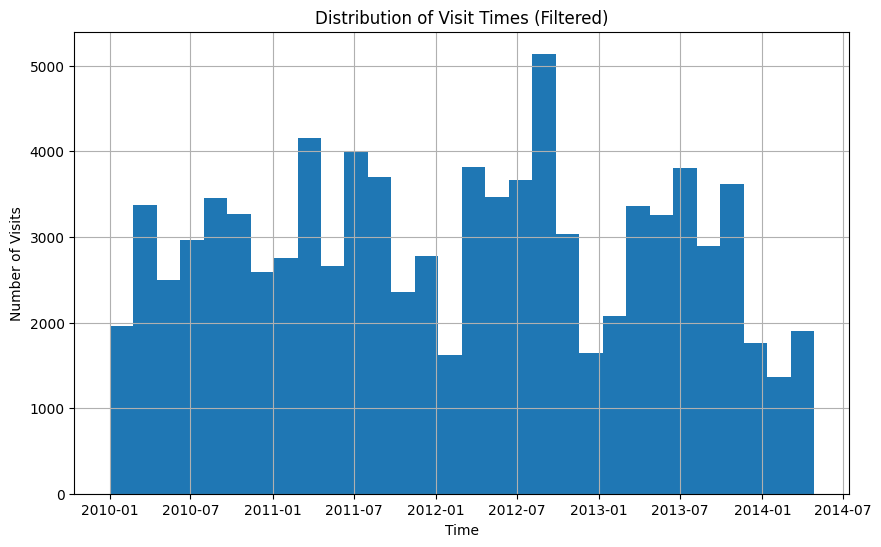

Column 'category' not found in poiList or 'cost' not found in the group by


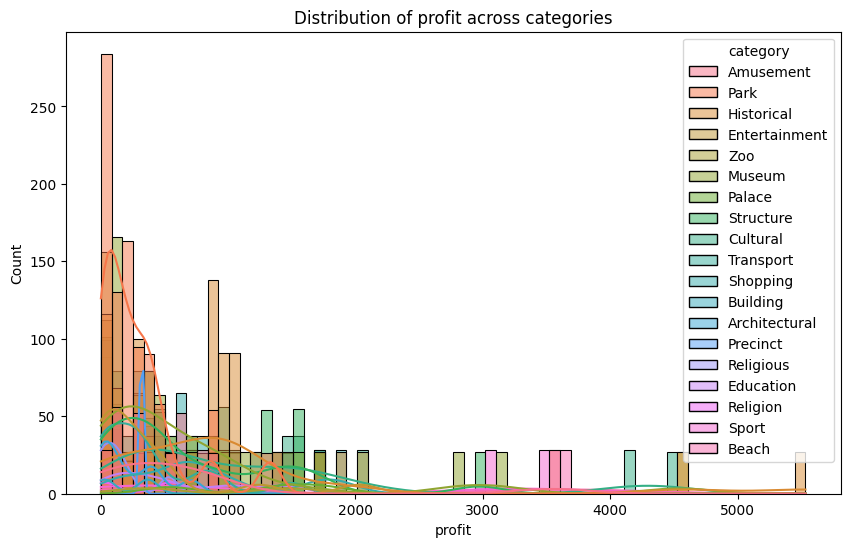

In [ ]:
# Convert 'dateTaken' to datetime objects, handling potential errors
try:
    userVisits['dateTaken'] = pd.to_datetime(userVisits['dateTaken'], unit='s', errors='coerce')
except KeyError:
    print("'dateTaken' column not found. Please check your data.")
    exit()  # Or handle the error appropriately


#Rename dateTaken to time
userVisits = userVisits.rename(columns={'dateTaken': 'time'})


# Exploratory Data Analysis

# 1. Data Description
print("User Visits Data:")
print(userVisits.describe(include='all'))
print("\nPOI List Data:")
print(poiList.describe(include='all'))
print("\nCost-Profit Category Data:")
print(costProfCat.describe(include='all'))

# 2. Check for missing values
print("\nMissing Values:")
print("User Visits:\n", userVisits.isnull().sum())
print("POI List:\n", poiList.isnull().sum())
print("Cost-Profit Category:\n", costProfCat.isnull().sum())

# 3. Data Visualization (examples)

# Example 1: Number of visits per city
plt.figure(figsize=(10, 6))
sns.countplot(x='cities', data=userVisits)
plt.title('Number of Visits per City')
plt.xlabel('City')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.show()

# Example 2: Distribution of visit times (if 'time' column exists and is datetime)
userVisits_filtered = userVisits[(userVisits['time'].dt.year >= 2010)]

# Replot the distribution of visit times
plt.figure(figsize=(10, 6))
userVisits_filtered['time'].hist(bins=30)  # Adjust bins as needed
plt.title('Distribution of Visit Times (Filtered)')
plt.xlabel('Time')
plt.ylabel('Number of Visits')
plt.show()

# Example 3 (if 'category' column exists in poiList): Relationship between POI category and average cost
# Handle potential KeyError
try:
    poi_cost = poiList.groupby('category')['cost'].mean().reset_index()  # Assuming a 'cost' column

    plt.figure(figsize=(12, 6))
    sns.barplot(x='category', y='cost', data=poi_cost)
    plt.title('Average POI Cost per Category')
    plt.xlabel('POI Category')
    plt.ylabel('Average Cost')
    plt.xticks(rotation=90, ha='right')
    plt.show()
except KeyError:
    print("Column 'category' not found in poiList or 'cost' not found in the group by")

# Example 4 (if 'category' column exists in costProfCat) Distribution of profit across categories
try:
    plt.figure(figsize=(10, 6))
    sns.histplot(x="profit", hue="category", data=costProfCat, kde=True) # Assuming 'profit' column in costProfCat
    plt.title("Distribution of profit across categories")
    plt.show()
except KeyError:
    print("Column 'category' or 'profit' not found in costProfCat.")

# ... (Add more visualizations as needed) ...

#Further analysis with more visualizations can be performed if needed.

## Ide Cerita

1. Popularitas Destinasi Wisata:

Ide Cerita: Membandingkan popularitas delapan kota dalam dataset berdasarkan jumlah kunjungan pengguna.
Visualisasi: Grafik batang atau heatmap yang menunjukkan jumlah kunjungan untuk setiap kota.
2. Rute Perjalanan dan Preferensi POI:

Ide Cerita: Menganalisis rute perjalanan pengguna di setiap kota dan mengidentifikasi preferensi mereka terhadap kategori POI tertentu.
Visualisasi: Peta dengan garis yang menunjukkan rute perjalanan pengguna, dengan POI ditandai berdasarkan kategori. Atau, bar chart yang menunjukkan kategori POI yang paling sering dikunjungi di setiap kota.
3. Faktor Biaya dan Keuntungan:

Ide Cerita: Explore hubungan antara biaya, keuntungan, dan popularitas berbagai kategori POI.
Visualisasi: Scatter plot yang menunjukkan hubungan antara biaya dan keuntungan untuk setiap kategori POI, dengan ukuran titik mewakili popularitas (jumlah kunjungan). Atau, diagram batang yang membandingkan biaya rata-rata dan keuntungan rata-rata untuk setiap kategori POI.
4. Pola Kunjungan Berdasarkan Waktu:

Ide Cerita: Menganalisis pola kunjungan pengguna berdasarkan waktu, seperti hari dalam seminggu, jam dalam sehari, atau musim.
Visualisasi: Grafik garis atau heatmap yang menunjukkan jumlah kunjungan berdasarkan waktu.
5. Perbandingan Antar Kota:

Ide Cerita: Membandingkan karakteristik dan pola kunjungan di delapan kota, seperti kategori POI yang populer, biaya rata-rata, dan distribusi waktu kunjungan.
Visualisasi: Grafik batang atau tabel yang membandingkan berbagai metrik antar kota. Atau, peta dengan penanda berbeda untuk setiap kota, menunjukkan karakteristik atau pola kunjungan yang berbeda.

## Pertanyaan Visualisasi

1. Popularitas Destinasi Wisata:

Pertanyaan:
Berapa total jumlah kunjungan untuk setiap kota?
Kota mana yang memiliki jumlah kunjungan tertinggi?
Bagaimana distribusi kunjungan di delapan kota tersebut?
Apakah ada outlier dalam hal jumlah kunjungan?<br>
Metode Visualisasi:
Grafik batang: Untuk membandingkan total jumlah kunjungan untuk setiap kota.
Heatmap: Untuk memvisualisasikan distribusi kunjungan di peta geografis.
Pie chart: Untuk menunjukkan proporsi kunjungan untuk setiap kota.
2. Rute Perjalanan dan Preferensi POI:

Pertanyaan:
Apa urutan kunjungan POI yang paling umum di setiap kota?
Kategori POI mana yang paling sering dikunjungi di setiap kota?
Apakah ada korelasi antara urutan kunjungan POI dan kategorinya?
Apakah pengguna cenderung mengunjungi POI dalam kategori yang sama dalam jarak dekat?<br>
Metode Visualisasi:
Network graph: Untuk merepresentasikan hubungan antara POI dan rute perjalanan pengguna.
Diagram Sankey: Untuk memvisualisasikan aliran kunjungan pengguna antara berbagai kategori POI.
Choropleth map: Untuk menampilkan kepadatan kunjungan POI berdasarkan kategori di area geografis.
3. Faktor Biaya dan Keuntungan:

Pertanyaan:
Berapa biaya dan keuntungan rata-rata untuk setiap kategori POI?
Apakah ada korelasi antara biaya dan keuntungan dari suatu kategori POI?
Apakah popularitas suatu kategori POI memengaruhi biaya atau keuntungannya?
Apakah ada kategori POI yang populer dan menguntungkan?<br>
Metode Visualisasi:
Scatter plot: Untuk menunjukkan hubungan antara biaya dan keuntungan untuk setiap kategori POI.
Bubble chart: Untuk memvisualisasikan hubungan antara biaya, keuntungan, dan popularitas.
Box plot: Untuk membandingkan distribusi biaya dan keuntungan di berbagai kategori POI.
4. Pola Kunjungan Berdasarkan Waktu:

Pertanyaan:
Bagaimana jumlah kunjungan bervariasi berdasarkan hari dalam seminggu, jam dalam sehari, atau musim?
Apakah ada pola atau tren dalam waktu kunjungan?
Apakah ada perbedaan signifikan dalam pola kunjungan antar kota?
Kapan waktu kunjungan puncak untuk setiap kota?<br>
Metode Visualisasi:
Line Chart: Untuk menunjukkan tren kunjungan dari waktu ke waktu.
Heatmap: Untuk memvisualisasikan kepadatan kunjungan di berbagai periode waktu.
Calendar heatmap: Untuk menampilkan pola kunjungan selama berhari-hari dan berminggu-minggu.
5. Perbandingan Antar Kota:

Pertanyaan:
Bagaimana delapan kota tersebut dibandingkan dalam hal kategori POI, biaya rata-rata, dan distribusi waktu kunjungan?
Apakah ada karakteristik berbeda yang membedakan kota-kota tersebut?
Kota mana yang menawarkan kategori POI paling beragam?
Kota mana yang paling mahal atau terjangkau untuk dikunjungi?<br>
Metode Visualisasi:
Bar chart: Untuk membandingkan berbagai metrik antar kota.
Grafik radar: Untuk memvisualisasikan profil keseluruhan setiap kota berdasarkan banyak faktor.
Parallel coordinates plot: Untuk membandingkan distribusi beberapa variabel antar kota.

In [ ]:
# prompt: jadi saya ingin membuat visualisasi dengan map peta dunia, dengan dataframe poiList dimana terdapat fitur (poiID  poiName lat  long theme cities) yang anda dapat gunakan untuk membuat titik untuk setiap poiID nya, dimana poiID yang digunakan adalah dari cities nya. jadi misalkan pada kolom cities yaitu Delh, maka nantinya pada dataset Delh dilihat untuk poiID nya. dimana poiID anda dapat gabungkan dengan dataframe userVisits ['photoID', 'userID', 'dateTaken', 'poiID', 'poiTheme', 'poiFreq', 'seqID', 'cities'] yang bisa anda gunakan poiFreq sebagai frekuensi kunjungan per poiID nya. lalu untuk setiap titik dari tempatnya gunakan poiName. Kemudian poiFreqnya itu memang sudah total jadi jangan dijumlahkan! karena cities nya dari berbagai kota, jadi jadikan plotnya 2d dengan perkotanya misal Glas berarti pada kota glas diberikan warna sesuai dengan poiFreq di kota itu. kemudian setiap plot per kota itu di zoom setiap titiknya

import pandas as pd
import plotly.express as px

# Assuming poiList and userVisits dataframes are already loaded as in the provided code

# Merge the two dataframes based on 'poiID' and 'cities'
merged_df = pd.merge(userVisits, poiList, on=['poiID', 'cities'], how='left')

# Group by city and calculate the sum of poiFreq for each city
city_freq = merged_df.groupby('cities')['poiFreq'].sum().reset_index()

# Create the map visualization
fig = px.scatter_mapbox(merged_df,
                        lat="lat",
                        lon="long",
                        hover_name="poiName",
                        hover_data=["poiFreq"],
                        color="poiFreq",
                        zoom=10, # Adjust the zoom level as needed
                        mapbox_style="open-street-map",
                        title="POI Frequency by City",
                        animation_frame = "cities") # add animation


fig.show()